# ML Foundations — Adult Income Prediction

Predict whether an individual earns more than $50K per year using the Adult Census Income dataset.

## 1. Problem Definition & Success Metric

**Target:** Predict whether income is above $50K (positive class = 1) or at/below $50K (negative class = 0).

**Business objective:** Identify people likely to earn more than $50K so outreach can focus on promising customers and reduce wasted effort on lower-income individuals.

**Primary metric:** F1 score.

**Metric trade-off:** Precision alone would reduce wasted outreach but miss many actual high-income people. Recall alone would find more of them but increase false targets. F1 balances both, which fits this problem.

**Summary:** The goal is to identify people likely to earn more than $50K so the business can focus outreach on the most promising customers. F1 score is used as the primary measure because it balances correctly identifying high-income people with avoiding incorrect targeting of lower-income people.

## 2. Dataset Loading & Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()

df = df.rename(columns={"class": "income"})

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# Convert ? (with optional whitespace) to NaN
df = df.replace(r"^\s*\?$", np.nan, regex=True)

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [4]:
# Convert target to binary: <=50K -> 0, >50K -> 1
print("Original income distribution:")
print(df["income"].value_counts())

df["income"] = df["income"].astype(str).map({"<=50K": 0, ">50K": 1})

print("\nBinary target distribution:")
print(df["income"].value_counts())

positive_rate = df["income"].mean()
print(f"\nPositive class base rate: {positive_rate * 100:.2f}%")

Original income distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Binary target distribution:
income
0    37155
1    11687
Name: count, dtype: int64

Positive class base rate: 23.93%


## 3. Quick EDA

In [5]:
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Data types:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income               int64
dtype: object


In [6]:
print("Numeric summary:")
df.describe()

Numeric summary:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [7]:
categorical_cols = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().head(10))


=== workclass ===
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

=== occupation ===
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service      

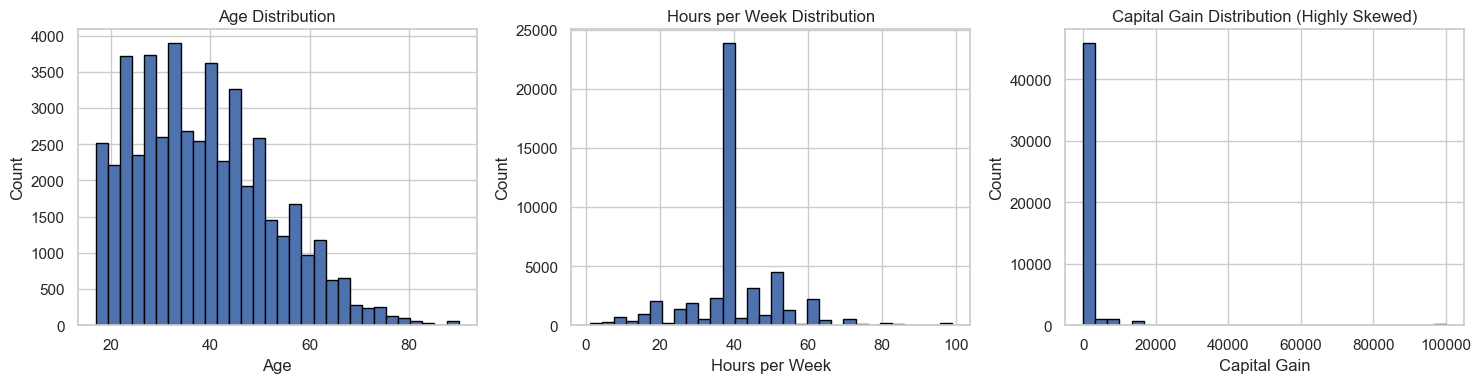

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["age"].hist(bins=30, ax=axes[0], edgecolor="black")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution")

df["hours-per-week"].hist(bins=30, ax=axes[1], edgecolor="black")
axes[1].set_xlabel("Hours per Week")
axes[1].set_ylabel("Count")
axes[1].set_title("Hours per Week Distribution")

df["capital-gain"].hist(bins=30, ax=axes[2], edgecolor="black")
axes[2].set_xlabel("Capital Gain")
axes[2].set_ylabel("Count")
axes[2].set_title("Capital Gain Distribution (Highly Skewed)")

plt.tight_layout()
plt.show()

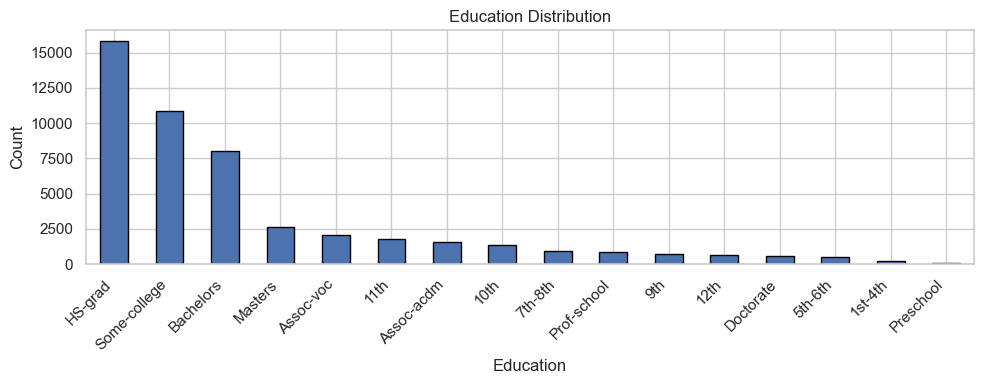

In [9]:
df["education"].value_counts().plot(kind="bar", figsize=(10, 4), edgecolor="black")
plt.xlabel("Education")
plt.ylabel("Count")
plt.title("Education Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
income_counts = df["income"].value_counts().sort_index()

summary = pd.DataFrame({
    "Feature": ["Income (target)", "Age", "Hours-per-week", "Capital-gain", "Education"],
    "Type": ["Target", "Numeric", "Numeric", "Numeric", "Categorical"],
    "Summary": [
        f"0 (<=50K): {income_counts.get(0, 0):,} | 1 (>50K): {income_counts.get(1, 0):,} | Positive rate: {positive_rate * 100:.2f}%",
        f"Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Min={df['age'].min()}, Max={df['age'].max()}",
        f"Mean={df['hours-per-week'].mean():.1f}, Median={df['hours-per-week'].median():.1f}, Min={df['hours-per-week'].min()}, Max={df['hours-per-week'].max()}",
        f"Mean={df['capital-gain'].mean():.1f}, Median={df['capital-gain'].median():.1f}, Max={df['capital-gain'].max():,.0f} (many zeros)",
        f"Top: {df['education'].value_counts().index[0]} ({df['education'].value_counts().iloc[0]:,})",
    ],
})

summary

,Feature,Type,Summary
0,Income (target),Target,"0 (<=50K): 37,155 | 1 (>50K): 11,687 | Positiv..."
1,Age,Numeric,"Mean=38.6, Median=37.0, Min=17, Max=90"
2,Hours-per-week,Numeric,"Mean=40.4, Median=40.0, Min=1, Max=99"
3,Capital-gain,Numeric,"Mean=1079.1, Median=0.0, Max=99,999 (many zeros)"
4,Education,Categorical,"Top: HS-grad (15,784)"


The dataset is imbalanced (~76% negative, ~24% positive). Capital-gain is heavily skewed toward zero. HS-grad and Bachelors are the most common education levels. Missing values appear in workclass, occupation, and native-country.

## 4. Reproducible Train/Test Split

A hold-out test set gives an unbiased estimate of performance on unseen data. Using it during tuning can lead to overfitting on the test split, so it is kept separate until final evaluation. The split below is 80/20 with `random_state=42` and `stratify=y`.

In [11]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train size: {len(X_train):,} ({len(X_train) / len(df) * 100:.1f}%)")
print(f"Test size:  {len(X_test):,} ({len(X_test) / len(df) * 100:.1f}%)")
print(f"\nTrain positive rate: {y_train.mean() * 100:.2f}%")
print(f"Test positive rate:  {y_test.mean() * 100:.2f}%")

Train size: 39,073 (80.0%)
Test size:  9,769 (20.0%)

Train positive rate: 23.93%
Test positive rate:  23.93%


## 5. Simple Baselines

### Baseline 1 — Majority Class

Always predict the most frequent class from the training set.

In [12]:
majority_class = y_train.mode()[0]
print(f"Majority class in training set: {majority_class} ({'<=50K' if majority_class == 0 else '>50K'})")

y_pred_majority = np.full(len(y_test), majority_class)

Majority class in training set: 0 (<=50K)


### Baseline 2 — Rule-Based Classifier

Predict `>50K` when `education-num >= 13`. Higher education levels generally correlate with higher income in this dataset.

In [13]:
education_mapping = (
    df[["education", "education-num"]]
    .drop_duplicates()
    .sort_values("education-num")
)
print("Education to education-num mapping:")
print(education_mapping.to_string(index=False))

Education to education-num mapping:
   education  education-num
   Preschool              1
     1st-4th              2
     5th-6th              3
     7th-8th              4
         9th              5
        10th              6
        11th              7
        12th              8
     HS-grad              9
Some-college             10
   Assoc-voc             11
  Assoc-acdm             12
   Bachelors             13
     Masters             14
 Prof-school             15
   Doctorate             16


In [14]:
y_pred_rule = (X_test["education-num"] >= 13).astype(int)
print(f"Rule predicts >50K for {y_pred_rule.sum():,} / {len(y_pred_rule):,} test samples ({y_pred_rule.mean() * 100:.1f}%)")

Rule predicts >50K for 2,399 / 9,769 test samples (24.6%)


## 6. Baseline Evaluation

In [15]:
def evaluate_model(y_true, y_pred, y_score=None):
    """Return accuracy, precision, recall, F1, ROC AUC, and PR AUC."""
    if y_score is None:
        y_score = y_pred

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
        "PR AUC": average_precision_score(y_true, y_score),
    }


majority_results = evaluate_model(y_test, y_pred_majority)
rule_results = evaluate_model(y_test, y_pred_rule)

results = pd.DataFrame(
    [majority_results, rule_results],
    index=["Majority Baseline", "Education Rule (edu-num >= 13)"],
)

results.round(4)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Baseline,0.7607,0.0000,0.000,0.0000,0.5000,0.2393
Education Rule (edu-num >= 13),0.7530,0.4844,0.497,0.4906,0.6653,0.3611


## 7. Confusion Matrices

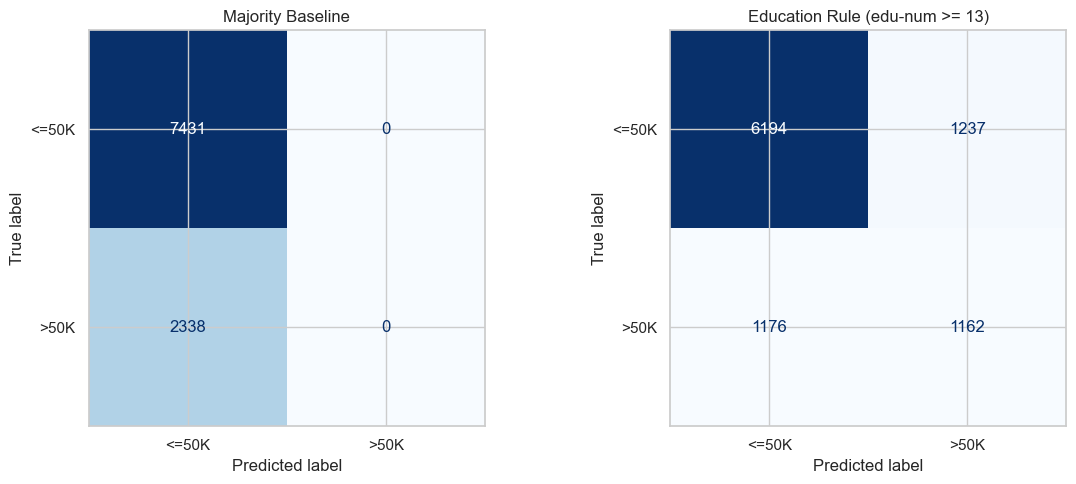

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_majority),
    display_labels=["<=50K", ">50K"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Majority Baseline")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rule),
    display_labels=["<=50K", ">50K"],
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Education Rule (edu-num >= 13)")

plt.tight_layout()
plt.show()

### Baseline Interpretation

The majority baseline gets about 76% accuracy by predicting everyone as `<=50K`, but its F1 for the positive class is 0 because it never identifies high-income individuals. The education rule has slightly lower accuracy (~75%) but reaches F1 ≈ 0.49, so it is the stronger baseline. A more advanced model would need to beat F1 = 0.49 by a clear margin to be worth using.

## 8. Error Analysis (Education Rule)

In [17]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["predicted"] = y_pred_rule.values

fp = error_analysis[(error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1)]
fn = error_analysis[(error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0)]

print(f"False Positives: {len(fp):,}")
print(f"False Negatives: {len(fn):,}")

False Positives: 1,237
False Negatives: 1,176


In [18]:
display_cols = [
    "age", "education", "education-num", "occupation",
    "hours-per-week", "capital-gain", "marital-status", "actual", "predicted",
]

print("=== 10 False Positives (predicted >50K, actually <=50K) ===")
fp[display_cols].head(10)

=== 10 False Positives (predicted >50K, actually <=50K) ===


,age,education,education-num,occupation,hours-per-week,capital-gain,marital-status,actual,predicted
38546,42,Doctorate,16,Prof-specialty,40,0,Married-civ-spouse,0,1
18199,25,Bachelors,13,Prof-specialty,35,0,Never-married,0,1
2271,24,Bachelors,13,Adm-clerical,20,0,Never-married,0,1
35730,37,Masters,14,Sales,50,0,Never-married,0,1
44616,35,Bachelors,13,Exec-managerial,40,0,Married-civ-spouse,0,1
7541,23,Bachelors,13,Tech-support,50,0,Never-married,0,1
42512,26,Masters,14,Tech-support,25,0,Never-married,0,1
5805,53,Bachelors,13,Sales,50,0,Never-married,0,1
36308,40,Bachelors,13,Prof-specialty,40,0,Divorced,0,1
38118,40,Masters,14,Exec-managerial,20,0,Separated,0,1


In [19]:
print("=== 10 False Negatives (predicted <=50K, actually >50K) ===")
fn[display_cols].head(10)

=== 10 False Negatives (predicted <=50K, actually >50K) ===


,age,education,education-num,occupation,hours-per-week,capital-gain,marital-status,actual,predicted
31692,47,Assoc-acdm,12,Protective-serv,40,0,Married-civ-spouse,1,0
11488,38,HS-grad,9,Transport-moving,40,0,Married-civ-spouse,1,0
33956,68,Some-college,10,Sales,40,20051,Married-civ-spouse,1,0
45549,26,Some-college,10,Protective-serv,55,0,Married-civ-spouse,1,0
9863,56,Some-college,10,Exec-managerial,54,0,Married-civ-spouse,1,0
30035,42,Some-college,10,Exec-managerial,40,0,Never-married,1,0
29836,43,Assoc-acdm,12,Sales,50,7688,Married-civ-spouse,1,0
41420,50,Assoc-voc,11,Tech-support,38,0,Married-civ-spouse,1,0
17615,51,Assoc-voc,11,Prof-specialty,40,0,Married-civ-spouse,1,0
32445,57,Some-college,10,Sales,50,0,Married-civ-spouse,1,0


In [20]:
# Summary statistics for error patterns
print("=== False Positive vs Correct Positive Comparison ===")
tp = error_analysis[(error_analysis["actual"] == 1) & (error_analysis["predicted"] == 1)]

for col in ["age", "hours-per-week", "capital-gain"]:
    print(f"\n{col}:")
    print(f"  FP mean: {fp[col].mean():.1f}  |  TP mean: {tp[col].mean():.1f}")

print("\n=== Top occupations in False Positives ===")
print(fp["occupation"].value_counts().head(5))

print("\n=== Top occupations in False Negatives ===")
print(fn["occupation"].value_counts().head(5))

=== False Positive vs Correct Positive Comparison ===

age:
  FP mean: 37.2  |  TP mean: 43.9

hours-per-week:
  FP mean: 40.1  |  TP mean: 46.0

capital-gain:
  FP mean: 196.1  |  TP mean: 6061.1

=== Top occupations in False Positives ===
occupation
Prof-specialty     428
Exec-managerial    224
Sales              163
Adm-clerical       141
Tech-support        57
Name: count, dtype: int64

=== Top occupations in False Negatives ===
occupation
Craft-repair       258
Exec-managerial    203
Sales              160
Prof-specialty      93
Adm-clerical        89
Name: count, dtype: int64


### Findings

False positives often have Bachelors-level or higher education but still earn <=50K, frequently in lower-paying occupations such as Adm-clerical or Other-service. False negatives include high-income people with education-num below 13 who show other signals such as higher capital-gain, longer hours, or professional occupations. Education alone is not enough; occupation, capital-gain, and hours-per-week also matter.

## 9. Data/Feature Issues Identified

1. Missing values in workclass, occupation, and native-country
2. Categorical columns need encoding before modeling
3. Skewed numeric features (capital-gain, capital-loss)
4. Class imbalance (~24% positive)
5. Single-feature rule is too limited
6. Feature interactions such as education + occupation are not captured

## 10. Conclusion

F1 remains the primary metric because the goal is to identify people earning >$50K while limiting both false positives and false negatives. The majority baseline reached F1 = 0.00, and the education rule reached F1 = 0.4906. Further modeling work will aim to improve on that result while keeping precision and recall at reasonable levels.

In [21]:
print(f"Dataset rows: {len(df):,}")
print(f"Features: {X.shape[1]}")
print(f"Positive class rate: {positive_rate * 100:.2f}%")
print(f"Negative class rate: {(1 - positive_rate) * 100:.2f}%")
print()
print(results.round(4).to_string())

Dataset rows: 48,842
Features: 14
Positive class rate: 23.93%
Negative class rate: 76.07%

                                Accuracy  Precision  Recall      F1  ROC AUC  PR AUC
Majority Baseline                 0.7607     0.0000   0.000  0.0000   0.5000  0.2393
Education Rule (edu-num >= 13)    0.7530     0.4844   0.497  0.4906   0.6653  0.3611
